In [204]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [205]:
df = pd.read_csv("cleaned_data/egx30.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date').sort_index()

In [206]:
df.shape

(2754, 6)

In [207]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2754 entries, 2015-01-04 to 2026-04-30
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   price       2754 non-null   float64
 1   open        2754 non-null   float64
 2   high        2754 non-null   float64
 3   low         2754 non-null   float64
 4   vol         2743 non-null   float64
 5   change_pct  2754 non-null   float64
dtypes: float64(6)
memory usage: 150.6 KB


In [208]:
df.head()

,price,open,high,low,vol,change_pct
date,,,,,,
2015-01-04,8942.65,8926.26,8942.65,8880.21,62.86,0.18
2015-01-05,9011.07,8941.72,9033.07,8931.80,86.76,0.77
2015-01-06,8798.94,8971.93,8971.93,8754.87,105.19,-2.35
2015-01-08,8946.34,8819.61,8954.29,8819.61,82.04,1.68
2015-01-11,8909.75,8945.69,8957.59,8909.75,45.71,-0.41


In [209]:
df.tail()

,price,open,high,low,vol,change_pct
date,,,,,,
2026-04-26,52421.14,52375.39,52632.40,52327.40,699.41,0.09
2026-04-27,52719.12,52421.14,52865.76,52353.93,341.83,0.57
2026-04-28,52230.61,52719.12,52896.87,52213.64,402.73,-0.93
2026-04-29,52383.13,52230.61,52431.85,52096.15,420.47,0.29
2026-04-30,51760.97,52383.13,52538.84,51748.64,637.54,-1.19


In [210]:
#print null count
print(df.isnull().sum())

price          0
open           0
high           0
low            0
vol           11
change_pct     0
dtype: int64


In [211]:
#fill missing values in volume colummn with mean
df['vol'] = df['vol'].fillna(df['vol'].mean())

In [212]:
#Computing daily % return 
df['return'] = df['price'].pct_change() * 100 

In [213]:
#Adding lag features
df['return_lag1'] = df['return'].shift(1)
df['return_lag2'] = df['return'].shift(2)

In [214]:
#Adding rolling features
df['ma_20']         = df['price'].rolling(20).mean()
df['volatility_20'] = df['return'].rolling(20).std()
df['ma_5']          = df['price'].rolling(5).mean()

In [215]:
df['dist_to_ma5'] = (df['price'] / df['ma_5']) - 1
df['dist_to_ma20'] = (df['price'] / df['ma_20']) - 1

In [216]:
# 1. Calculate the Fast (12-day) and Slow (26-day) Exponential Moving Averages (EMA)
ema_12 = df['price'].ewm(span=12, adjust=False).mean()
ema_26 = df['price'].ewm(span=26, adjust=False).mean()

# 2. Calculate the raw MACD line
df['macd'] = ema_12 - ema_26

# 3. Calculate the Signal Line (9-day EMA of the MACD)
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()

# 4. Calculate the MACD Histogram (The most useful feature for ML)
# This represents the distance between the MACD and its signal line
df['macd_hist'] = df['macd'] - df['macd_signal']

# What this does: A rising macd_hist means short-term momentum is accelerating upward.

In [217]:
# 1. Calculate the 20-day SMA (Middle Band) and 20-day Standard Deviation
window = 20
sma_20 = df['price'].rolling(window=window).mean()
std_20 = df['price'].rolling(window=window).std()

# 2. Calculate Upper and Lower Bands
upper_band = sma_20 + (std_20 * 2)
lower_band = sma_20 - (std_20 * 2)

# 3. Feature A: Bollinger %B (Where is price relative to the bands?)
# Value of 1.0 = price is touching upper band. Value of 0.0 = touching lower band.
df['bb_pb'] = (df['price'] - lower_band) / (upper_band - lower_band)

# 4. Feature B: Bollinger Bandwidth (How volatile is the market right now?)
# Useful for detecting "squeezes" before explosive moves.
df['bb_bandwidth'] = (upper_band - lower_band) / sma_20

In [218]:
#Adding RSI
delta = df['price'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
df['rsi'] = 100 - (100 / (1 + gain / loss))

In [219]:
threshold = 0.005

future_return = df['return'].shift(-1)

df['label'] = (future_return > threshold).astype(int)

In [220]:
#Adding rolling features adds NaN rows
df = df.dropna()

In [221]:
df.drop(columns=['price', 'ma_5', 'ma_20'], inplace=True)

In [222]:
# Note for modeling team: price, ma_5, ma_20 are in EGP price scale
# while return, rsi etc. are percentages. Please apply StandardScaler or MinMaxScaler before training.
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2734 entries, 2015-02-03 to 2026-04-30
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   open           2734 non-null   float64
 1   high           2734 non-null   float64
 2   low            2734 non-null   float64
 3   vol            2734 non-null   float64
 4   change_pct     2734 non-null   float64
 5   return         2734 non-null   float64
 6   return_lag1    2734 non-null   float64
 7   return_lag2    2734 non-null   float64
 8   volatility_20  2734 non-null   float64
 9   dist_to_ma5    2734 non-null   float64
 10  dist_to_ma20   2734 non-null   float64
 11  macd           2734 non-null   float64
 12  macd_signal    2734 non-null   float64
 13  macd_hist      2734 non-null   float64
 14  bb_pb          2734 non-null   float64
 15  bb_bandwidth   2734 non-null   float64
 16  rsi            2734 non-null   float64
 17  label          2734 non-null   int64  
dtypes

In [223]:
df.head()

,open,high,low,vol,change_pct,return,return_lag1,return_lag2,volatility_20,dist_to_ma5,dist_to_ma20,macd,macd_signal,macd_hist,bb_pb,bb_bandwidth,rsi,label
date,,,,,,,,,,,,,,,,,,
2015-02-03,9835.43,9961.67,9835.43,152.66,1.26,1.260165,0.518418,-0.643496,1.250556,0.010154,0.042740,231.878160,217.738825,14.139336,0.761924,0.163179,77.883585,1
2015-02-04,9960.63,10066.11,9957.28,108.85,0.92,0.920101,1.260165,0.518418,1.252472,0.015693,0.046662,237.883633,221.767786,16.115847,0.792124,0.159732,74.752646,0
2015-02-05,10046.28,10046.28,9945.59,96.19,-0.80,-0.801320,0.920101,1.260165,1.101889,0.005068,0.032003,233.456198,224.105469,9.350730,0.726049,0.141577,68.914923,0
2015-02-08,9965.08,10041.67,9957.57,75.48,-0.08,-0.075260,-0.801320,0.920101,1.083881,0.000715,0.025853,226.728650,224.630105,2.098545,0.706429,0.125240,70.052125,0
2015-02-09,9956.03,9956.03,9883.69,93.90,-0.74,-0.737804,-0.075260,-0.801320,1.101427,-0.007746,0.013198,213.013122,222.306708,-9.293586,0.633563,0.098812,63.334081,1


In [224]:
df.tail()

,open,high,low,vol,change_pct,return,return_lag1,return_lag2,volatility_20,dist_to_ma5,dist_to_ma20,macd,macd_signal,macd_hist,bb_pb,bb_bandwidth,rsi,label
date,,,,,,,,,,,,,,,,,,
2026-04-26,52375.39,52632.40,52327.40,699.41,0.09,0.087350,0.794806,-0.028763,1.643830,0.005972,0.066035,1360.803979,977.986832,382.817147,0.814784,0.209778,81.245847,1
2026-04-27,52421.14,52865.76,52353.93,341.83,0.57,0.568435,0.087350,0.794806,1.586429,0.008186,0.065254,1399.541644,1062.297794,337.243850,0.809526,0.210820,81.068389,0
2026-04-28,52719.12,52896.87,52213.64,402.73,-0.93,-0.926628,0.568435,0.087350,1.441527,-0.002123,0.047929,1374.973016,1124.832839,250.140177,0.741898,0.198138,86.152639,1
2026-04-29,52230.61,52431.85,52096.15,420.47,0.29,0.292013,-0.926628,0.568435,1.441517,-0.000815,0.043597,1352.221720,1170.310615,181.911105,0.739250,0.182222,82.032740,0
2026-04-30,52383.13,52538.84,51748.64,637.54,-1.19,-1.187711,0.292013,-0.926628,1.388328,-0.010363,0.026061,1269.355699,1190.119632,79.236067,0.652254,0.171169,72.160911,0


In [225]:
#return is the same as change_pct so we can drop change_pct
print((df['return'].round(2) == df['change_pct'].round(2)).value_counts())

True     2733
False       1
Name: count, dtype: int64


In [226]:
df.drop(columns=['open', 'high', 'low', 'change_pct'], inplace=True)

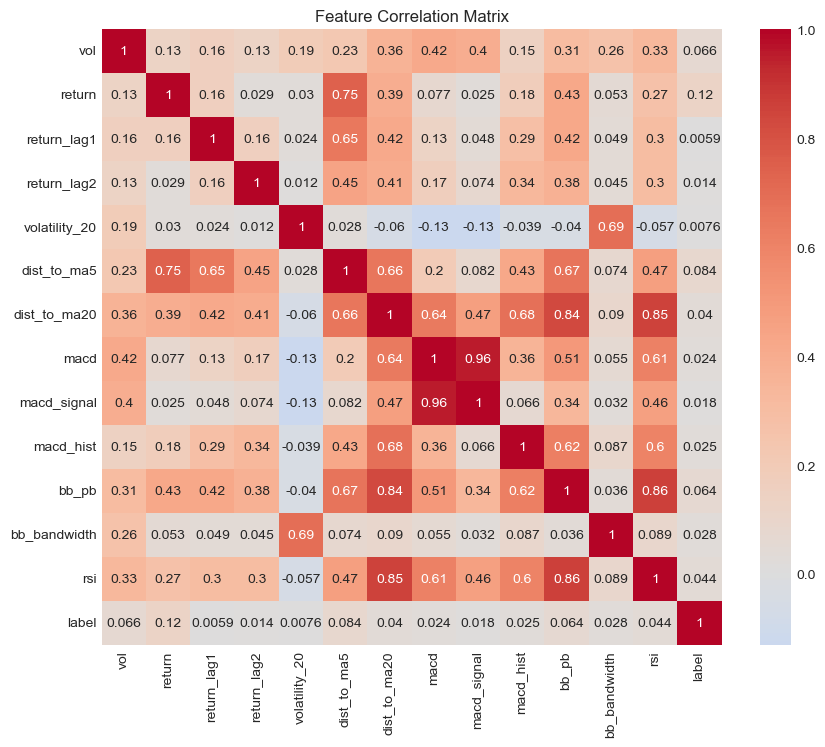

In [234]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [235]:
df.corr()

,vol,return,return_lag1,return_lag2,volatility_20,dist_to_ma5,dist_to_ma20,macd,macd_signal,macd_hist,bb_pb,bb_bandwidth,rsi,label
vol,1.000000,0.132336,0.161580,0.130452,0.189624,0.225724,0.364792,0.416215,0.398642,0.145826,0.308028,0.261448,0.331104,0.065648
return,0.132336,1.000000,0.158875,0.029373,0.030098,0.748092,0.390598,0.076666,0.024836,0.181861,0.428209,0.053407,0.271057,0.118154
return_lag1,0.161580,0.158875,1.000000,0.158882,0.024244,0.652025,0.420319,0.129139,0.048401,0.285387,0.421694,0.049404,0.301114,0.005934
return_lag2,0.130452,0.029373,0.158882,1.000000,0.012137,0.451236,0.405850,0.168248,0.074427,0.335553,0.375215,0.045004,0.297540,0.013656
volatility_20,0.189624,0.030098,0.024244,0.012137,1.000000,0.027835,-0.060212,-0.131061,-0.127593,-0.039329,-0.039654,0.691442,-0.057007,0.007620
dist_to_ma5,0.225724,0.748092,0.652025,0.451236,0.027835,1.000000,0.661763,0.202815,0.081976,0.429191,0.667260,0.073666,0.472812,0.084283
dist_to_ma20,0.364792,0.390598,0.420319,0.405850,-0.060212,0.661763,1.000000,0.640988,0.469836,0.684189,0.835850,0.089967,0.854882,0.040466
macd,0.416215,0.076666,0.129139,0.168248,-0.131061,0.202815,0.640988,1.000000,0.956111,0.355686,0.506318,0.054994,0.610056,0.024292
macd_signal,0.398642,0.024836,0.048401,0.074427,-0.127593,0.081976,0.469836,0.956111,1.000000,0.066233,0.344878,0.031511,0.461737,0.018126
macd_hist,0.145826,0.181861,0.285387,0.335553,-0.039329,0.429191,0.684189,0.355686,0.066233,1.000000,0.624161,0.086769,0.604684,0.024907


In [236]:
df.drop(columns=['dist_to_ma20', 'macd', 'macd_signal', 'volatility_20'], inplace=True)

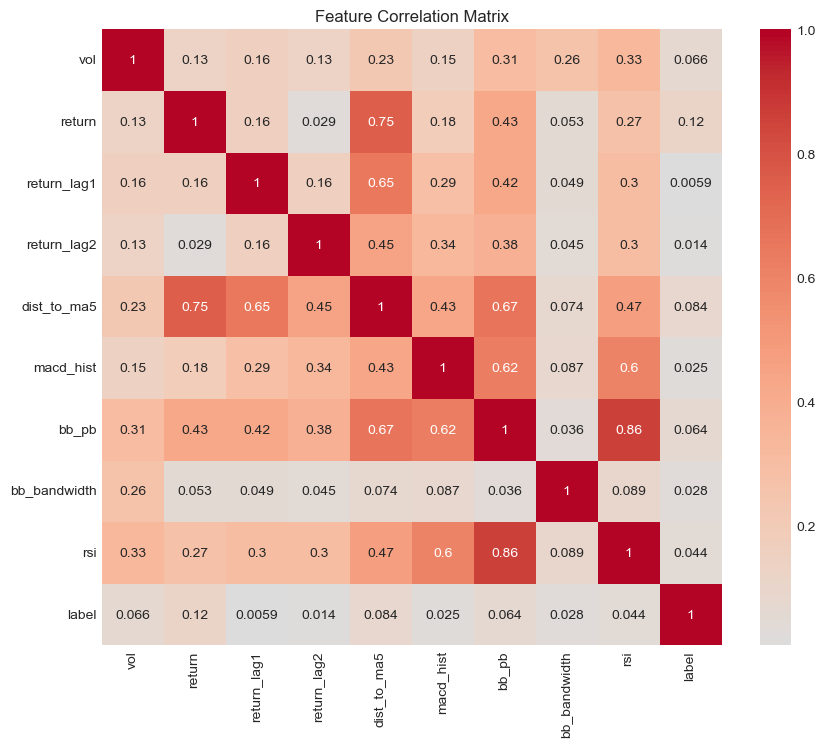

In [237]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [238]:
df.corr()

,vol,return,return_lag1,return_lag2,dist_to_ma5,macd_hist,bb_pb,bb_bandwidth,rsi,label
vol,1.000000,0.132336,0.161580,0.130452,0.225724,0.145826,0.308028,0.261448,0.331104,0.065648
return,0.132336,1.000000,0.158875,0.029373,0.748092,0.181861,0.428209,0.053407,0.271057,0.118154
return_lag1,0.161580,0.158875,1.000000,0.158882,0.652025,0.285387,0.421694,0.049404,0.301114,0.005934
return_lag2,0.130452,0.029373,0.158882,1.000000,0.451236,0.335553,0.375215,0.045004,0.297540,0.013656
dist_to_ma5,0.225724,0.748092,0.652025,0.451236,1.000000,0.429191,0.667260,0.073666,0.472812,0.084283
macd_hist,0.145826,0.181861,0.285387,0.335553,0.429191,1.000000,0.624161,0.086769,0.604684,0.024907
bb_pb,0.308028,0.428209,0.421694,0.375215,0.667260,0.624161,1.000000,0.035589,0.860679,0.064281
bb_bandwidth,0.261448,0.053407,0.049404,0.045004,0.073666,0.086769,0.035589,1.000000,0.089313,0.027716
rsi,0.331104,0.271057,0.301114,0.297540,0.472812,0.604684,0.860679,0.089313,1.000000,0.043797
label,0.065648,0.118154,0.005934,0.013656,0.084283,0.024907,0.064281,0.027716,0.043797,1.000000


In [239]:
sns.set_theme(style="darkgrid", palette="muted")

C:\Users\moata\AppData\Local\Temp\ipykernel_28052\2791296911.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])


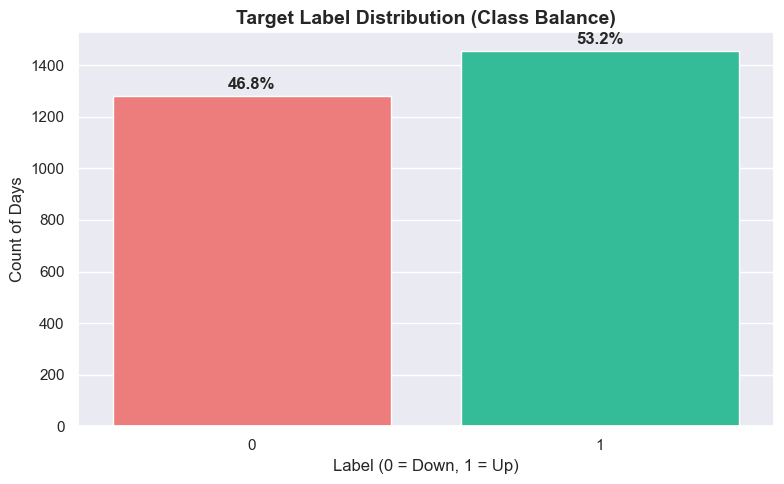

In [241]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='label', palette=['#ff6b6b', '#1dd1a1'])

# Add title and labels
plt.title("Target Label Distribution (Class Balance)", fontsize=14, fontweight='bold')
plt.xlabel("Label (0 = Down, 1 = Up)", fontsize=12)
plt.ylabel("Count of Days", fontsize=12)

# Calculate and add percentage text on top of the bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + (total * 0.01) # slight offset above bar
    ax.annotate(percentage, (x, y), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

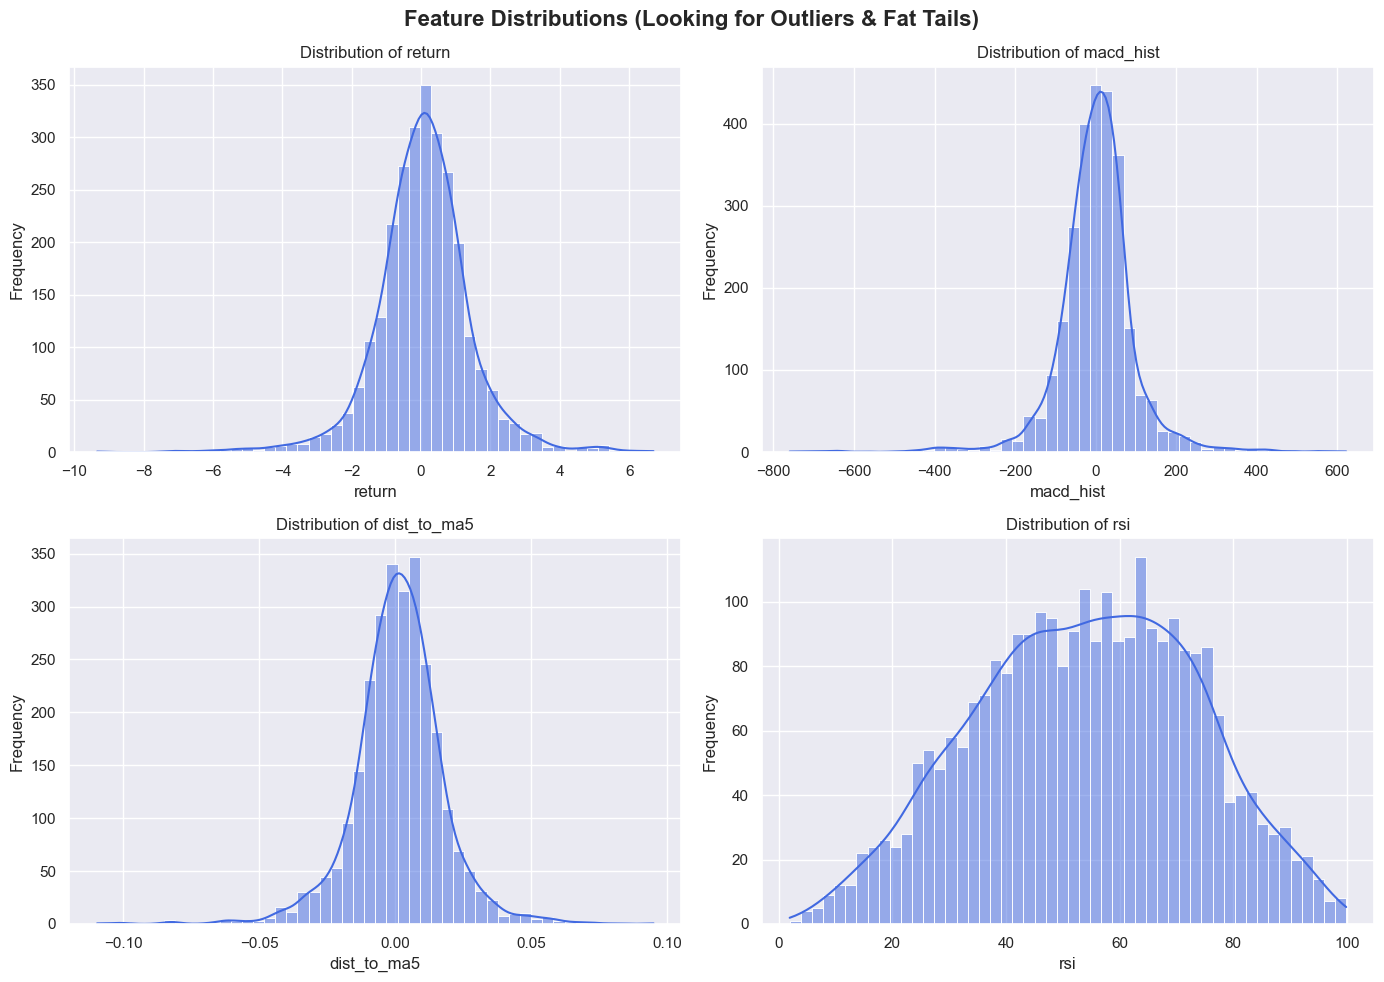

In [242]:
features_to_plot = ['return', 'macd_hist', 'dist_to_ma5', 'rsi']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Feature Distributions (Looking for Outliers & Fat Tails)", fontsize=16, fontweight='bold')

# Flatten axes for easy looping
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.histplot(df[feature], kde=True, ax=axes[i], color='royalblue', bins=50)
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

C:\Users\moata\AppData\Local\Temp\ipykernel_28052\1749860680.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
C:\Users\moata\AppData\Local\Temp\ipykernel_28052\1749860680.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
C:\Users\moata\AppData\Local\Temp\ipykernel_28052\1749860680.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='label', y=feature, ax=axes[i], pal

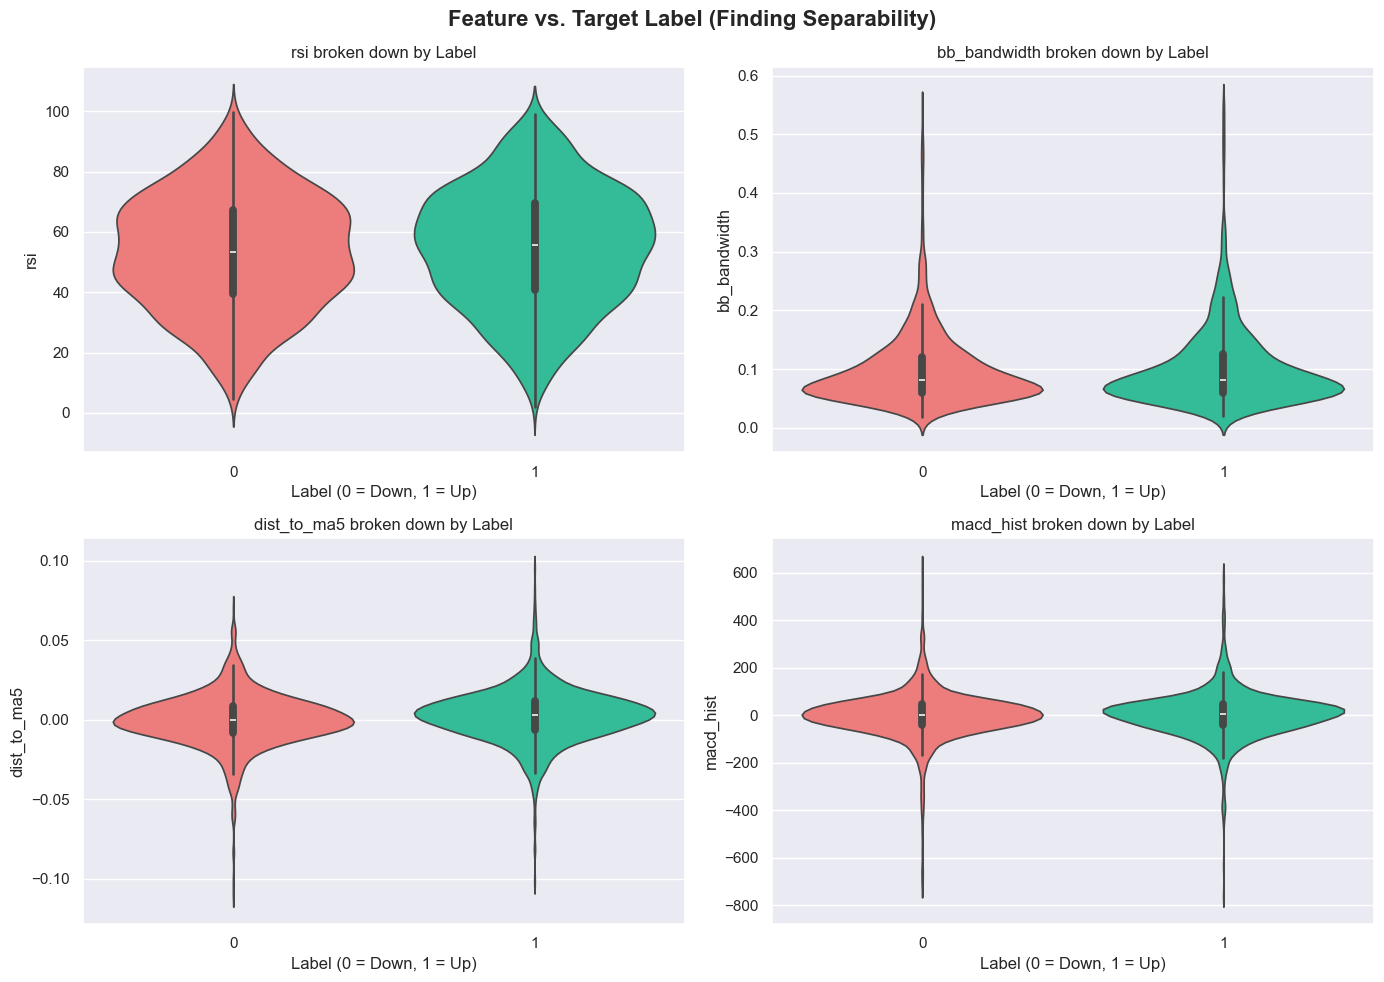

In [244]:
features_to_plot = ['rsi', 'bb_bandwidth', 'dist_to_ma5', 'macd_hist']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Feature vs. Target Label (Finding Separability)", fontsize=16, fontweight='bold')

axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    # Violin plot splits the distribution by the label
    sns.violinplot(data=df, x='label', y=feature, ax=axes[i], palette=['#ff6b6b', '#1dd1a1'])
    axes[i].set_title(f"{feature} broken down by Label")
    axes[i].set_xlabel("Label (0 = Down, 1 = Up)")

plt.tight_layout()
plt.show()

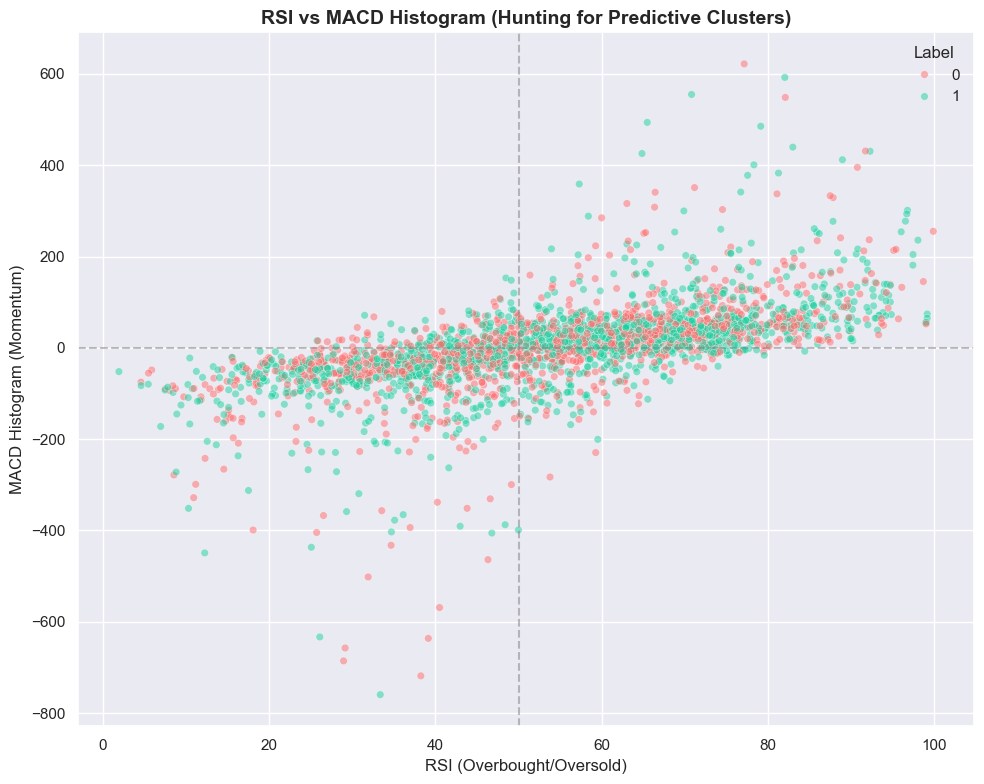

In [245]:
plt.figure(figsize=(10, 8))

# Scatter plot: X is RSI (momentum), Y is MACD (trend), colored by the label
sns.scatterplot(
    data=df, 
    x='rsi', 
    y='macd_hist', 
    hue='label', 
    palette=['#ff6b6b', '#1dd1a1'], # Red for 0, Green for 1
    alpha=0.5, # Makes overlapping dots transparent
    s=30       # Size of dots
)

plt.title("RSI vs MACD Histogram (Hunting for Predictive Clusters)", fontsize=14, fontweight='bold')
plt.xlabel("RSI (Overbought/Oversold)", fontsize=12)
plt.ylabel("MACD Histogram (Momentum)", fontsize=12)
plt.axvline(50, color='gray', linestyle='--', alpha=0.5) # RSI midpoint
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)  # MACD midpoint

plt.legend(title='Label')
plt.tight_layout()
plt.show()

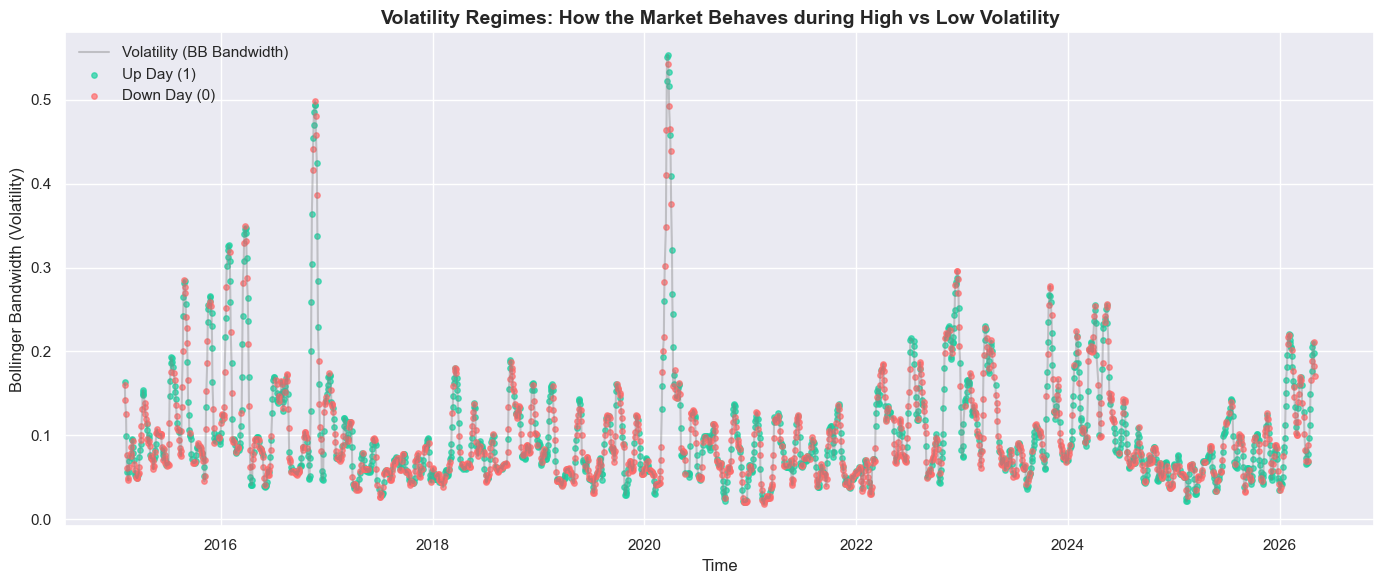

In [246]:
plt.figure(figsize=(14, 6))

# Plot the baseline volatility as a gray line
plt.plot(df.index, df['bb_bandwidth'], color='gray', alpha=0.4, label='Volatility (BB Bandwidth)')

# Overlay Green dots for Up days (Label 1)
up_days = df[df['label'] == 1]
plt.scatter(up_days.index, up_days['bb_bandwidth'], color='#1dd1a1', s=15, alpha=0.7, label='Up Day (1)')

# Overlay Red dots for Down days (Label 0)
down_days = df[df['label'] == 0]
plt.scatter(down_days.index, down_days['bb_bandwidth'], color='#ff6b6b', s=15, alpha=0.7, label='Down Day (0)')

plt.title("Volatility Regimes: How the Market Behaves during High vs Low Volatility", fontsize=14, fontweight='bold')
plt.xlabel("Time", fontsize=12)
plt.ylabel("Bollinger Bandwidth (Volatility)", fontsize=12)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [248]:
df.to_csv('final_data/final_EGX30.csv')